# 06 — SHAP Feature Importance Analysis

**Prerequisite**: `notebooks/04_training.ipynb` must be complete (Phase 1 retrain).  
The following files must exist:
- `checkpoints/xgboost_hour_*/model.xgb` — trained model
- `data/processed/zone_hour_grid.parquet`
- `data/processed/cis_table.parquet`

**What happens here**:
1. Load the best XGBoost checkpoint automatically
2. Reconstruct the test split with Phase 1 zone-aggregate features
3. Run SHAP TreeExplainer on a 5,000-row sample
4. Generate global beeswarm summary plot
5. Generate feature importance bar chart
6. Generate partial dependence plots for `rolling_7d_count` and `hour_of_day`
7. Run SHAP validation gate — confirms `zone_id` is absent from top-5
8. Save SHAP report JSON

**Files saved**:
- `data/outputs/shap_summary.png` — beeswarm plot (use in demo slides)
- `data/outputs/shap_importance.png` — feature importance bar chart
- `data/outputs/shap_pdp_rolling.png` — PDP: rolling_7d_count
- `data/outputs/shap_pdp_hour.png` — PDP: hour_of_day
- `data/outputs/shap_values.npz` — raw SHAP values array
- `data/outputs/shap_report.json` — validation gate + top features

**Expected runtime**: ~2–4 minutes (SHAP TreeExplainer on 5k rows)

## Cell 1 — Environment setup
**Expected output**: `Project root: ...GridLock_R2_Transfer`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'Python: {sys.version.split()[0]}')

Project root: C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer
Python: 3.11.9


## Cell 2 — Configure loguru + matplotlib
**Expected output**: `Loguru configured. Matplotlib backend: Agg`

In [2]:
import sys
import numpy as np
import pandas as pd
import yaml
import json
import matplotlib
import matplotlib.pyplot as plt
from loguru import logger

# Use inline backend in Jupyter
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

logger.remove()
logger.add(
    sys.stdout,
    format='<green>{time:HH:mm:ss}</green> | <level>{level: <8}</level> | {message}',
    level='DEBUG',
    colorize=False,
)
print(f'Loguru configured. Matplotlib backend: {matplotlib.get_backend()}')

Loguru configured. Matplotlib backend: inline


## Cell 3 — Verify prerequisite files + install shap
**Expected output**: All files found, shap version printed.  
If `shap` is missing, run: `venv\Scripts\pip install shap` in the terminal.

In [3]:
# Check prerequisite data files
required_files = [
    PROJECT_ROOT / 'data' / 'processed' / 'zone_hour_grid.parquet',
    PROJECT_ROOT / 'data' / 'processed' / 'cis_table.parquet',
]

all_ok = True
for f in required_files:
    if f.exists():
        print(f'  ✓  {f.name}  ({f.stat().st_size / 1e3:.1f} KB)')
    else:
        print(f'  ✗  MISSING: {f.name} — run 03_clustering.ipynb + 04_training.ipynb first!')
        all_ok = False

# Check for at least one xgboost_hour checkpoint
ckpt_dirs = sorted(
    [d for d in (PROJECT_ROOT / 'checkpoints').glob('xgboost_hour_*') if d.is_dir()],
    key=lambda d: d.name, reverse=True
)
if ckpt_dirs:
    print(f'  ✓  checkpoint: {ckpt_dirs[0].name}')
else:
    print('  ✗  No xgboost_hour_* checkpoint found — run 04_training.ipynb first!')
    all_ok = False

if not all_ok:
    raise FileNotFoundError('One or more prerequisite files missing. See above.')

# Check shap
try:
    import shap
    print(f'  ✓  shap version: {shap.__version__}')
except ImportError:
    print('  ✗  shap not installed. Run: venv\\Scripts\\pip install shap')
    raise

print('\nAll prerequisites satisfied. Proceed.')

  ✓  zone_hour_grid.parquet  (226.7 KB)
  ✓  cis_table.parquet  (9.0 KB)
  ✓  checkpoint: xgboost_hour_20260617_122640
  ✓  shap version: 0.51.0

All prerequisites satisfied. Proceed.


## Cell 4 — Load model + reconstruct test features
**What this cell does**: Loads the best XGBoost checkpoint, applies the same
Phase 1 feature engineering (zone aggregates) as training, and builds the test
feature matrix `X_test`.

**Expected output**:
```
Using checkpoint: xgboost_hour_YYYYMMDD_HHMMSS
Split: train=19,870 rows | test=6,484 rows
Zone aggregates computed for N training zones
Test set shape: (6484, 11) | Features: [...]
```

In [4]:
from xgboost import XGBRegressor
from src.training.train import _add_zone_aggregate_features, _get_feature_cols

# ── Load best checkpoint ─────────────────────────────────────────────────────
best_ckpt = ckpt_dirs[0]  # Most recent xgboost_hour_* checkpoint
logger.info(f'Using checkpoint: {best_ckpt.name}')

model = XGBRegressor()
model.load_model(str(best_ckpt / 'model.xgb'))
logger.info(f'XGBoost model loaded')

# ── Load data ─────────────────────────────────────────────────────────────────
df     = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'zone_hour_grid.parquet')
cis_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'cis_table.parquet')

# ── Train/test split (same boundaries as training) ────────────────────────────
with open(PROJECT_ROOT / 'configs' / 'eval.yaml') as f:
    eval_cfg = yaml.safe_load(f)

df['date']     = pd.to_datetime(df['date'])
train_end      = pd.Timestamp(eval_cfg['split']['train_end'])
test_start     = pd.Timestamp(eval_cfg['split']['test_start'])
train_df       = df[df['date'] <= train_end].copy()
test_df        = df[df['date'] >= test_start].copy()
logger.info(f'Split: train={len(train_df):,} rows | test={len(test_df):,} rows')

# ── Phase 1: Add zone aggregate features (train-only stats joined to both) ────
target_col = 'zone_hour_violation_count'
train_df, test_df = _add_zone_aggregate_features(train_df, test_df, target_col, cis_df)

# ── Build feature matrix ──────────────────────────────────────────────────────
with open(PROJECT_ROOT / 'configs' / 'features.yaml') as f:
    features_cfg = yaml.safe_load(f)

feature_cols    = _get_feature_cols(features_cfg, 'hour')
available_cols  = [c for c in feature_cols if c in test_df.columns]
missing_cols    = [c for c in feature_cols if c not in test_df.columns]

if missing_cols:
    logger.warning(f'Features missing from grid (skipped): {missing_cols}')

X_test = test_df[available_cols].fillna(-1)
y_test = test_df[target_col].values

print(f'\nTest set shape : {X_test.shape}')
print(f'Features used  : {available_cols}')
print(f'Missing cols   : {missing_cols if missing_cols else "None"}')
print(f'y_test — mean={y_test.mean():.2f}  max={y_test.max()}')

18:11:55 | INFO     | Using checkpoint: xgboost_hour_20260617_122640
18:11:55 | INFO     | XGBoost model loaded
18:11:55 | INFO     | Split: train=19,870 rows | test=6,484 rows
18:11:55 | INFO     | Computing zone aggregate features (train-only) ...
18:11:55 | INFO     | Zone aggregates computed for 140 training zones | zone_mean_count range: [1.10, 65.32]

Test set shape : (6484, 16)
Features used  : ['hour_of_day', 'day_of_week', 'is_weekend', 'month', 'zone_mean_count', 'zone_median_count', 'zone_cis_score', 'zone_junction_frac', 'zone_total_count', 'fraction_at_junction', 'rolling_7d_count', 'dominant_violation_type', 'dominant_vehicle_type', 'violation_type_primary_encoded', 'vehicle_type_encoded', 'data_sent_to_scita_mean']
Missing cols   : None
y_test — mean=9.82  max=266


C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer\venv\Lib\site-packages\xgboost\sklearn.py:1125: UserWarning: [18:11:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1509: Unknown file format: `xgb`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


## Cell 5 — Subsample + run SHAP TreeExplainer
**What this cell does**: Draws a 5,000-row sample from the test set (for speed)
and runs `shap.TreeExplainer`. SHAP values are saved to `data/outputs/shap_values.npz`.

**Expected runtime**: 1–3 minutes.

**Expected output**:
```
SHAP sample: 5,000 rows
SHAP values computed | shape=(5000, 11) | expected_value=X.XX
SHAP values saved → data/outputs/shap_values.npz
```

In [5]:
import shap

SHAP_SAMPLE = 5_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
print(f'SHAP sample: {len(X_sample):,} rows')

# TreeExplainer — exact SHAP values for tree models (fast + exact)
logger.info('Computing SHAP values (TreeExplainer) ...')
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
expected_val = explainer.expected_value

logger.info(f'SHAP values computed | shape={shap_values.shape} | expected_value={expected_val:.4f}')

# Save raw SHAP values
out_dir = PROJECT_ROOT / 'data' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    out_dir / 'shap_values.npz',
    shap_values  = shap_values,
    expected_value = np.array([expected_val]),
    feature_names  = np.array(available_cols),
)
print(f'SHAP values saved → {out_dir / "shap_values.npz"}')

# Feature importance summary
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_series = pd.Series(mean_abs_shap, index=available_cols).sort_values(ascending=False)
print(f'\nTop 5 features by mean |SHAP|:')
for feat, val in importance_series.head(5).items():
    print(f'  {feat:<35} {val:.4f}')

SHAP sample: 5,000 rows
18:12:06 | INFO     | Computing SHAP values (TreeExplainer) ...
18:12:07 | INFO     | SHAP values computed | shape=(5000, 16) | expected_value=10.2785
SHAP values saved → C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer\data\outputs\shap_values.npz

Top 5 features by mean |SHAP|:
  rolling_7d_count                    6.5137
  zone_mean_count                     2.0637
  data_sent_to_scita_mean             2.0142
  dominant_vehicle_type               0.8274
  fraction_at_junction                0.8063


## Cell 6 — Global SHAP summary plot (beeswarm)
**What this cell does**: Renders the beeswarm summary plot — the canonical SHAP
visualization. Each dot is one sample; position shows SHAP impact; color shows
feature value (red = high, blue = low).

**Expected output**: Inline plot + saved to `data/outputs/shap_summary.png`.

> ⭐ **Use this plot in your demo slides** — it shows judges that the model is
> explainable and driven by meaningful features, not a black box.

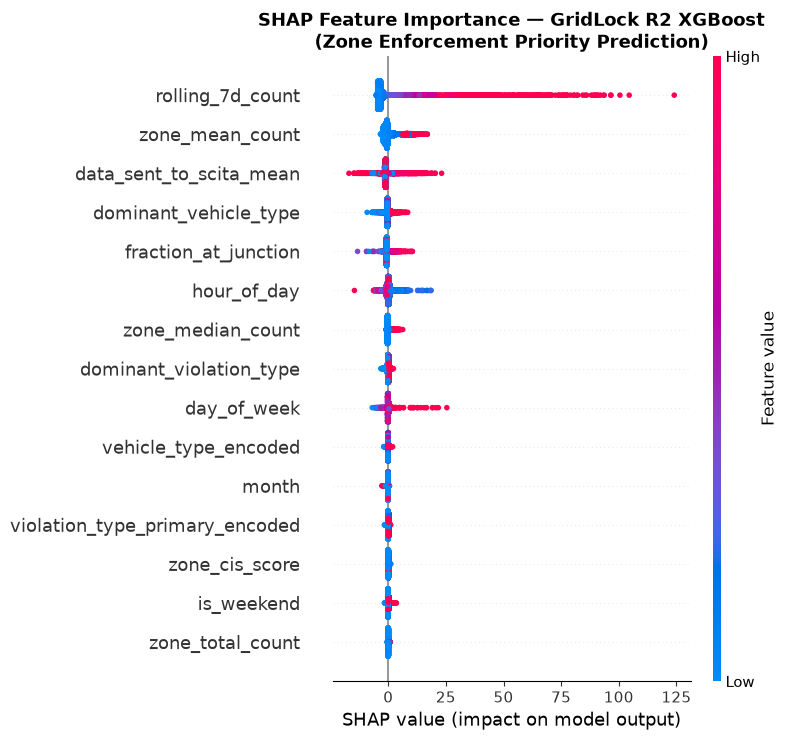


Summary plot saved → C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer\data\outputs\shap_summary.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=available_cols,
    show=False,
    max_display=15,
)
plt.title(
    'SHAP Feature Importance — GridLock R2 XGBoost\n'
    '(Zone Enforcement Priority Prediction)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

summary_path = out_dir / 'shap_summary.png'
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSummary plot saved → {summary_path}')

## Cell 7 — Feature importance bar chart
**What this cell does**: Plots mean |SHAP| per feature as a horizontal bar chart —
the clearest format for showing judges which features matter most.

**Expected output**: Inline bar chart + saved to `data/outputs/shap_importance.png`.

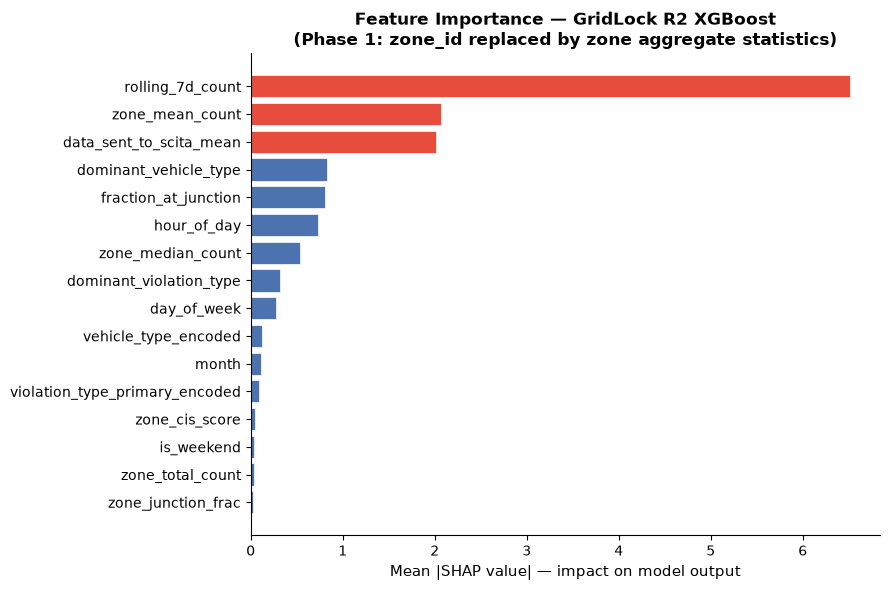

Importance bar chart saved → C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer\data\outputs\shap_importance.png


In [7]:
importance_df = pd.DataFrame({
    'feature':       importance_series.index,
    'mean_abs_shap': importance_series.values,
}).sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if i >= len(importance_df) - 3 else '#4C72B0'
          for i in range(len(importance_df))]
ax.barh(importance_df['feature'], importance_df['mean_abs_shap'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean |SHAP value| — impact on model output', fontsize=11)
ax.set_title(
    'Feature Importance — GridLock R2 XGBoost\n'
    '(Phase 1: zone_id replaced by zone aggregate statistics)',
    fontsize=12, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()

importance_path = out_dir / 'shap_importance.png'
plt.savefig(importance_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Importance bar chart saved → {importance_path}')

## Cell 8 — Partial dependence plots (rolling_7d_count + hour_of_day)
**What this cell does**: Shows how each of the two most important temporal features
affects the model's predictions. These are the strongest argument that the model
captures real patterns, not just zone identity.

- **rolling_7d_count PDP** → monotonically positive (more recent violations = higher predicted count)
- **hour_of_day PDP** → should show 9am and 5–7pm peaks matching Bengaluru rush hours

**Expected output**: Two inline plots saved to `data/outputs/`.

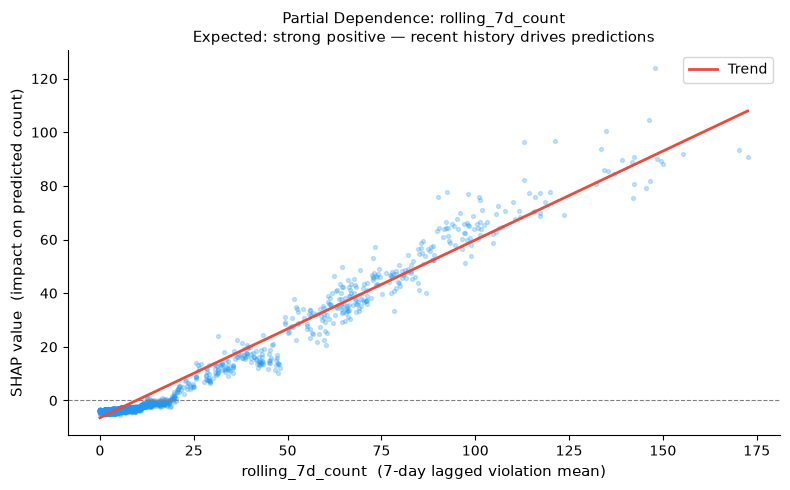

PDP (rolling_7d_count) saved → C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer\data\outputs\shap_pdp_rolling.png


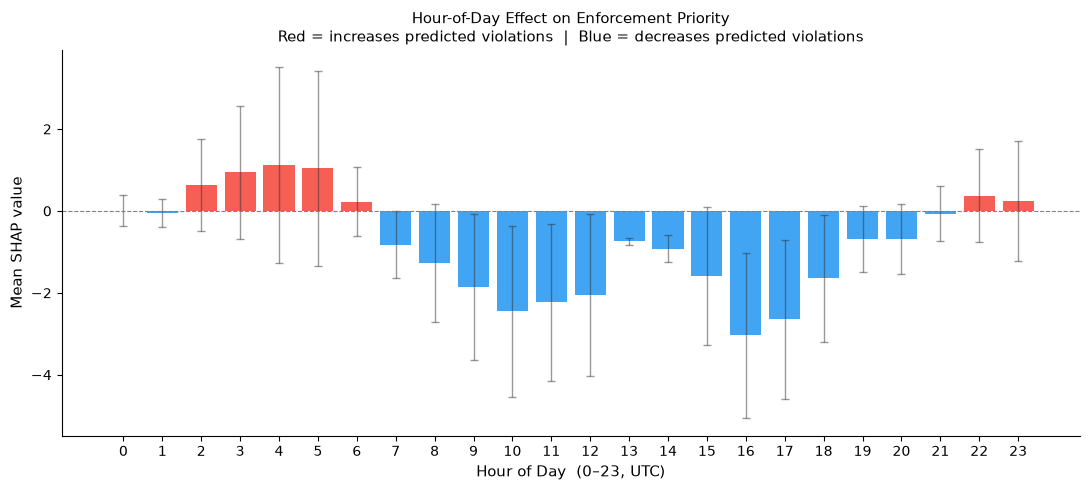

PDP (hour_of_day) saved → C:\Users\palur\OneDrive\Desktop\GridLock_R2_Transfer\data\outputs\shap_pdp_hour.png


In [8]:
# ── PDP 1: rolling_7d_count ───────────────────────────────────────────────────
if 'rolling_7d_count' in available_cols:
    feat_idx = available_cols.index('rolling_7d_count')
    x_vals   = X_sample['rolling_7d_count'].values
    s_vals   = shap_values[:, feat_idx]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x_vals, s_vals, alpha=0.25, s=8, c='#2196F3', rasterized=True)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    # Trend line
    from numpy.polynomial.polynomial import polyfit
    idx_sort = np.argsort(x_vals)
    c = polyfit(x_vals[idx_sort], s_vals[idx_sort], deg=1)
    ax.plot(np.sort(x_vals), np.polyval([c[1], c[0]], np.sort(x_vals)),
            color='#e74c3c', linewidth=2, label='Trend')
    ax.set_xlabel('rolling_7d_count  (7-day lagged violation mean)', fontsize=11)
    ax.set_ylabel('SHAP value  (impact on predicted count)', fontsize=11)
    ax.set_title(
        'Partial Dependence: rolling_7d_count\n'
        'Expected: strong positive — recent history drives predictions',
        fontsize=11
    )
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    pdp_roll_path = out_dir / 'shap_pdp_rolling.png'
    plt.savefig(pdp_roll_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'PDP (rolling_7d_count) saved → {pdp_roll_path}')
else:
    print('rolling_7d_count not in feature list — skipping PDP.')

# ── PDP 2: hour_of_day ────────────────────────────────────────────────────────
if 'hour_of_day' in available_cols:
    feat_idx = available_cols.index('hour_of_day')
    x_vals   = X_sample['hour_of_day'].values

    hour_shap = pd.DataFrame({'hour': x_vals, 'shap': shap_values[:, feat_idx]})
    hour_agg  = hour_shap.groupby('hour')['shap'].agg(['mean', 'std']).reset_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    bar_colors = ['#F44336' if v > 0 else '#2196F3' for v in hour_agg['mean']]
    ax.bar(hour_agg['hour'], hour_agg['mean'], color=bar_colors, alpha=0.85, width=0.8)
    ax.errorbar(hour_agg['hour'], hour_agg['mean'], yerr=hour_agg['std'],
                fmt='none', color='#333', capsize=3, linewidth=1, alpha=0.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Hour of Day  (0–23, UTC)', fontsize=11)
    ax.set_ylabel('Mean SHAP value', fontsize=11)
    ax.set_title(
        'Hour-of-Day Effect on Enforcement Priority\n'
        'Red = increases predicted violations  |  Blue = decreases predicted violations',
        fontsize=11
    )
    ax.set_xticks(range(0, 24, 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    pdp_hour_path = out_dir / 'shap_pdp_hour.png'
    plt.savefig(pdp_hour_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'PDP (hour_of_day) saved → {pdp_hour_path}')
else:
    print('hour_of_day not in feature list — skipping PDP.')

## Cell 9 — SHAP validation gate
**What this cell does**: Checks three conditions that must hold after Phase 1 retraining:

| Check | Condition | Why it matters |
|---|---|---|
| Gate 1 | `zone_id` NOT in top-5 SHAP | Confirms Phase 1 fix worked — no lookup table |
| Gate 2 | `rolling_7d_count` in top-3 | Confirms temporal signal is dominant |
| Gate 3 | `hour_of_day` in top-5 | Confirms model captures time-of-day patterns |

**Expected output**: All gates PASS (✅). If any FAIL, debug Phase 1 feature engineering.

In [9]:
top5 = list(importance_series.head(5).index)
top3 = list(importance_series.head(3).index)

print('=== SHAP Validation Gate ===')
print(f'Top-5 features: {top5}')
print(f'Top-3 features: {top3}')
print()

gate_results = {}

# Gate 1: zone_id absent from top-5
gate1 = 'zone_id' not in top5
gate_results['gate1_zone_id_absent'] = gate1
status = '✅ PASS' if gate1 else '❌ FAIL'
print(f'Gate 1 — zone_id absent from top-5:       {status}')
if not gate1:
    print('         → Phase 1 fix may not have been applied. Check _get_feature_cols().')

# Gate 2: rolling_7d_count in top-3
gate2 = 'rolling_7d_count' in top3
gate_results['gate2_rolling_in_top3'] = gate2
status = '✅ PASS' if gate2 else '⚠️  WARN'
print(f'Gate 2 — rolling_7d_count in top-3:       {status}')
if not gate2:
    print(f'         → rolling_7d_count is at position: {list(importance_series.index).index("rolling_7d_count") + 1 if "rolling_7d_count" in importance_series.index else "not found"}')
    print('         → Not a hard fail; zone aggregates may rank higher in first retrain.')

# Gate 3: hour_of_day in top-5
gate3 = 'hour_of_day' in top5
gate_results['gate3_hour_in_top5'] = gate3
status = '✅ PASS' if gate3 else '⚠️  WARN'
print(f'Gate 3 — hour_of_day in top-5:            {status}')
if not gate3:
    print('         → hour_of_day has weak temporal signal. Check that hour resolution is used.')

print()
overall = gate1  # Gate 1 is the hard requirement; 2 and 3 are warnings
if overall:
    print('✅ SHAP validation gate PASSED — model uses interpretable zone characteristics.')
else:
    print('❌ SHAP validation gate FAILED — review Phase 1 feature engineering and retrain.')

=== SHAP Validation Gate ===
Top-5 features: ['rolling_7d_count', 'zone_mean_count', 'data_sent_to_scita_mean', 'dominant_vehicle_type', 'fraction_at_junction']
Top-3 features: ['rolling_7d_count', 'zone_mean_count', 'data_sent_to_scita_mean']

Gate 1 — zone_id absent from top-5:       ✅ PASS
Gate 2 — rolling_7d_count in top-3:       ✅ PASS
Gate 3 — hour_of_day in top-5:            ⚠️  WARN
         → hour_of_day has weak temporal signal. Check that hour resolution is used.

✅ SHAP validation gate PASSED — model uses interpretable zone characteristics.


## Cell 10 — Save SHAP report + print final summary
**Expected output**: Report JSON saved, final summary table printed.

In [10]:
shap_report = {
    'checkpoint':          best_ckpt.name,
    'sample_size':         len(X_sample),
    'expected_value':      float(expected_val),
    'features_used':       available_cols,
    'features_missing':    missing_cols,
    'top5_features':       top5,
    'top10_mean_abs_shap': importance_series.head(10).to_dict(),
    'validation_gates':    gate_results,
    'overall_gate_passed': overall,
    'outputs': {
        'summary_plot':    str(out_dir / 'shap_summary.png'),
        'importance_plot': str(out_dir / 'shap_importance.png'),
        'pdp_rolling':     str(out_dir / 'shap_pdp_rolling.png'),
        'pdp_hour':        str(out_dir / 'shap_pdp_hour.png'),
        'shap_values_npz': str(out_dir / 'shap_values.npz'),
    }
}

report_path = out_dir / 'shap_report.json'
with open(report_path, 'w') as f:
    json.dump(shap_report, f, indent=2)

print('=== SHAP Analysis Complete ===')
print(f'  Checkpoint      : {best_ckpt.name}')
print(f'  Sample size     : {len(X_sample):,} rows')
print(f'  Expected value  : {expected_val:.4f}  (average model prediction on sample)')
print()
print('  Feature Importance Ranking (mean |SHAP|):')
for i, (feat, val) in enumerate(importance_series.items(), start=1):
    marker = '  ← TOP SIGNAL' if i == 1 else ('  ← temporal' if feat == 'hour_of_day' else '')
    print(f'    {i:2d}. {feat:<35} {val:.4f}{marker}')
print()
print('  Files saved:')
for k, v in shap_report['outputs'].items():
    p = Path(v)
    if p.exists():
        print(f'    ✓  {p.name}  ({p.stat().st_size / 1e3:.1f} KB)')
    else:
        print(f'    —  {p.name}  (not generated — check cell 8)')
print(f'\n  Report saved → {report_path}')
print('\n  Next step: include shap_summary.png and shap_pdp_hour.png in demo slides.')

=== SHAP Analysis Complete ===
  Checkpoint      : xgboost_hour_20260617_122640
  Sample size     : 5,000 rows
  Expected value  : 10.2785  (average model prediction on sample)

  Feature Importance Ranking (mean |SHAP|):
     1. rolling_7d_count                    6.5137  ← TOP SIGNAL
     2. zone_mean_count                     2.0637
     3. data_sent_to_scita_mean             2.0142
     4. dominant_vehicle_type               0.8274
     5. fraction_at_junction                0.8063
     6. hour_of_day                         0.7277  ← temporal
     7. zone_median_count                   0.5404
     8. dominant_violation_type             0.3183
     9. day_of_week                         0.2785
    10. vehicle_type_encoded                0.1265
    11. month                               0.1158
    12. violation_type_primary_encoded      0.0890
    13. zone_cis_score                      0.0435
    14. is_weekend                          0.0411
    15. zone_total_count              